<a href="https://colab.research.google.com/github/Ademola-Olorunnisola/Ademola-Olorunnisola.github.io/blob/main/Ademola%20training%20data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-2908555222.py:278: FutureWarning: Starting with pandas version 3.0 all arguments of to_hdf except for the argument 'path_or_buf' will be keyword-only.
  df_trimmed.to_hdf(fname, 'trajec')


Generated trajectory 1/10
Generated trajectory 2/10
Generated trajectory 3/10
Generated trajectory 4/10
Generated trajectory 5/10
Generated trajectory 6/10
Generated trajectory 7/10
Generated trajectory 8/10
Generated trajectory 9/10
Generated trajectory 10/10
Number of trajectories: 10


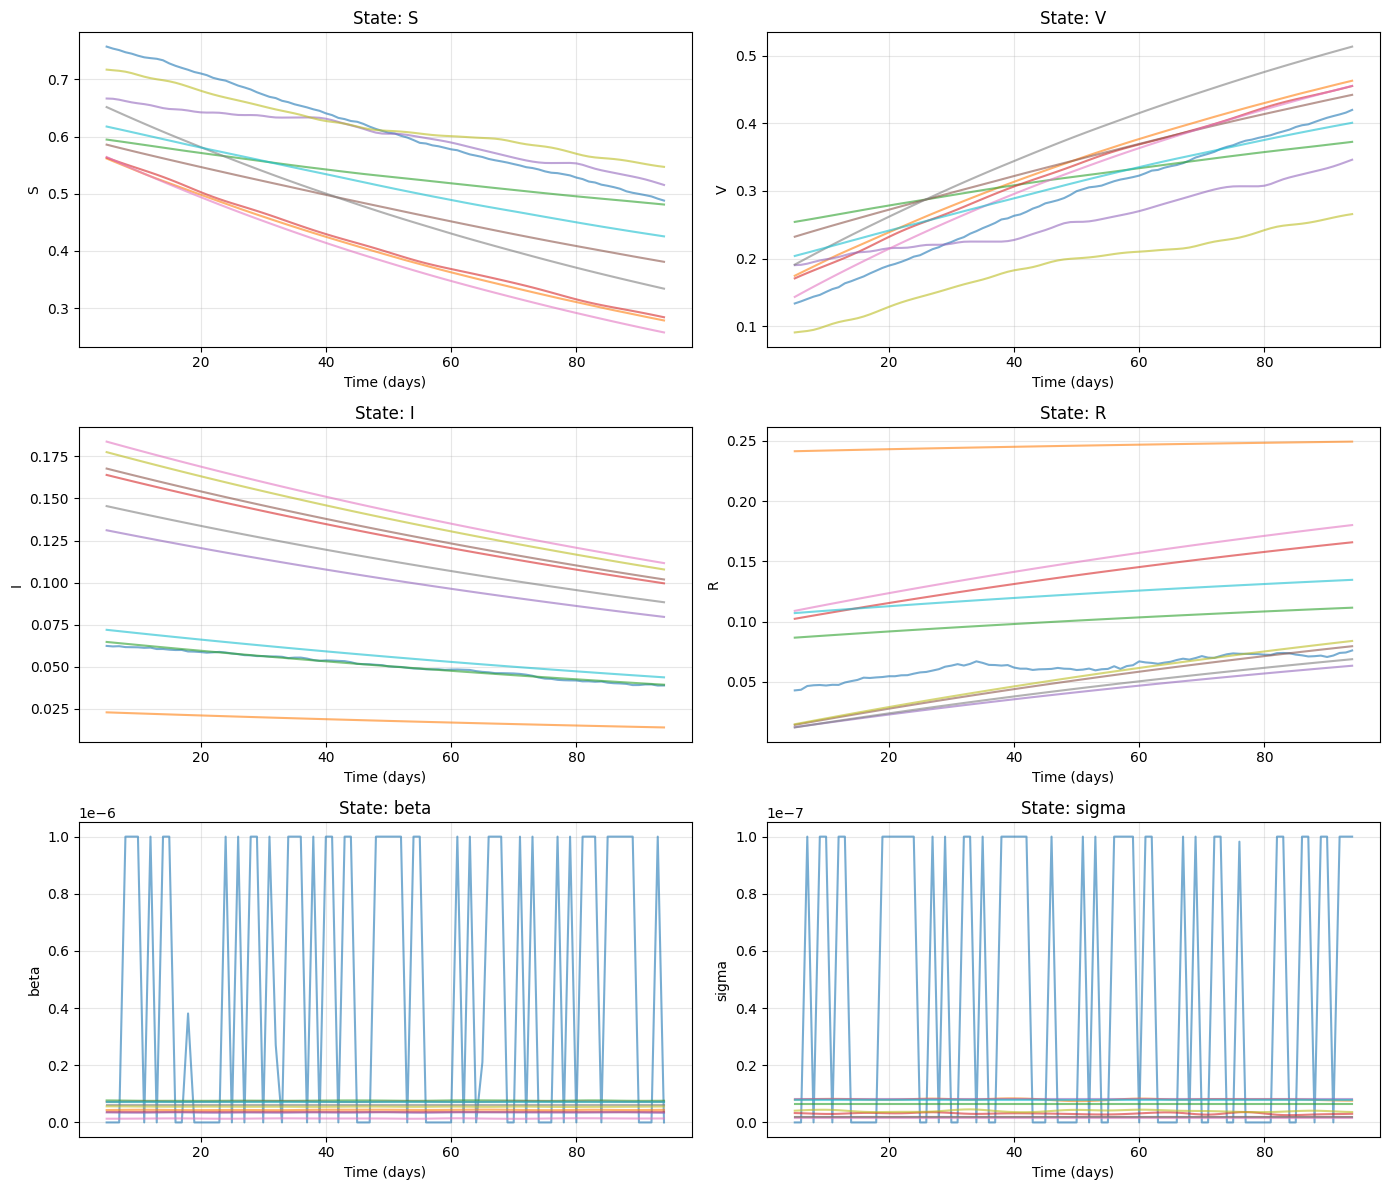

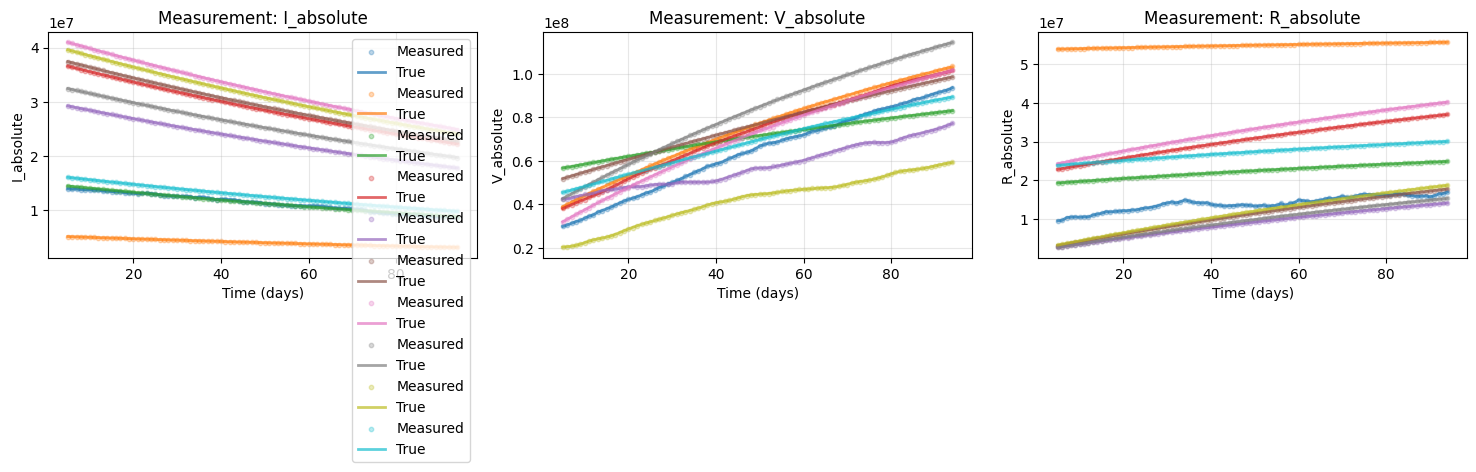


Training data generation complete!
Data saved in: tb_trajectories/
Total trajectories: 10


In [3]:
# Cell 1: Imports and setup
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas
import os
from scipy.integrate import odeint
from scipy.interpolate import UnivariateSpline

# Cell 2: TB model parameters
Lambda = 9.04e-5    # Recruitment rate per day
mu = 4.3e-5         # Mortality rate per day
gamma = 0.00555     # Removal rate per day
N = 223000000

# Cell 3: Define dynamics function (same as your UKF code)
def f(x_vec, u_vec, Lambda=Lambda, mu=mu, gamma=gamma, return_state_names=False):
    """
    Continuous time dynamics function for TB SVIR model.

    Parameters:
    x_vec : array-like, shape (6,)
        State vector [S, V, I, R, beta, sigma]
    u_vec : array-like, shape (2,)
        Control vector [alpha, kappa]
    """
    if return_state_names:
        return ['S', 'V', 'I', 'R', 'beta', 'sigma']

    # Extract state variables
    S = x_vec[0]
    V = x_vec[1]
    I = x_vec[2]
    R = x_vec[3]
    beta = x_vec[4]
    sigma = x_vec[5]

    # Extract control inputs
    alpha = u_vec[0]  # vaccination rate
    kappa = u_vec[1]  # social distancing effectiveness

    # f0 component: drift dynamics (no controls)
    f0_contribution = np.array([Lambda - beta * S * I - mu * S,
                                 -sigma * V * I - mu * V,
                                 beta*S*I + sigma*V*I - gamma*I - mu*I,
                                 gamma*I - mu*R,
                                 0,
                                 0])

    # f1 component: multiplied by control alpha (vaccination)
    f1_contribution = alpha * np.array([-S,
                                         S,
                                         0,
                                         0,
                                         0,
                                         0])

    # f2 component: multiplied by control kappa (social distancing)
    f2_contribution = kappa * np.array([beta*S*I,
                                         sigma*V*I,
                                         -beta*S*I - sigma*V*I,
                                         0,
                                         0,
                                         0])

    # Combined dynamics
    x_dot_vec = f0_contribution + f1_contribution + f2_contribution

    return x_dot_vec

# Cell 4: Define measurement function (matching your h_ivr)
def h(x_vec, u_vec=None, return_measurement_names=False):
    """
    Measurement function - observes I, V, R populations.
    Matches your h_ivr measurement model.
    """
    if return_measurement_names:
        return ['I_absolute', 'V_absolute', 'R_absolute']

    # Return in order: I, V, R (as fractions, will be converted to absolute)
    return np.array([x_vec[2], x_vec[1], x_vec[3]])

# Cell 5: Smooth curve generator
def generate_smooth_curve(t, method='spline', smoothness=0.5, amplitude=1.0,
                         baseline=0.0, seed=42):
    """
    Generate smooth random curves for control inputs.
    """
    np.random.seed(seed)
    n_points = len(t)

    if method == 'spline':
        # Generate sparse random points and interpolate
        n_knots = max(3, int(n_points * (1 - smoothness)))
        knot_indices = np.linspace(0, n_points-1, n_knots).astype(int)
        knot_values = np.random.uniform(-amplitude, amplitude, n_knots) + baseline

        # Spline interpolation
        spline = UnivariateSpline(t[knot_indices], knot_values, s=0, k=min(3, n_knots-1))
        curve = spline(t)

    elif method == 'noise_filter':
        # Generate noise and low-pass filter
        noise = np.random.randn(n_points)
        window = max(1, int(n_points * smoothness))
        kernel = np.ones(window) / window
        curve = np.convolve(noise, kernel, mode='same') * amplitude + baseline

    return curve

# Cell 6: Main simulation function
def simulate_snippet(dt, tsim_length, trim_indices,
                     # Control parameters
                     smoothness_alpha=0.5, smoothness_kappa=0.5,
                     amplitude_alpha=0.001, amplitude_kappa=0.3,
                     baseline_alpha=0.0005, baseline_kappa=0.1,
                     seed_alpha=42, seed_kappa=24,
                     trajectory_shape_alpha='spline',
                     trajectory_shape_kappa='spline',
                     # Initial conditions (as FRACTIONS)
                     S0=0.7, V0=0.1, I0=0.01, R0=0.19,
                     beta0=2e-8, sigma0=1e-8,
                     # Parameter variation
                     vary_beta=False, vary_sigma=False,
                     smoothness_beta=0.8, smoothness_sigma=0.8,
                     amplitude_beta=1e-9, amplitude_sigma=5e-10,
                     seed_beta=33, seed_sigma=44,
                     # Measurement noise (matching your UKF setup)
                     use_measurement_noise=True,
                     noise_std_I=10000.0,      # Absolute scale
                     noise_std_V=100000.0,     # Absolute scale
                     noise_std_R=5000.0,       # Absolute scale
                     # Process noise
                     use_process_noise=False,
                     Q_diag=None,
                     directory='tb_trajectories',
                     number=1):
    """
    Simulate a single TB SVIR trajectory.
    Matches your UKF data format exactly.
    """

    # Set the sim time
    tsim = np.arange(0, tsim_length, dt)
    n_steps = len(tsim)

    # Generate smooth random control trajectories
    alpha_curve = generate_smooth_curve(tsim, method=trajectory_shape_alpha,
                                       smoothness=smoothness_alpha,
                                       amplitude=amplitude_alpha,
                                       baseline=baseline_alpha,
                                       seed=seed_alpha)
    alpha_curve = np.clip(alpha_curve, 0, 1)  # Keep in valid range [0,1]

    kappa_curve = generate_smooth_curve(tsim, method=trajectory_shape_kappa,
                                       smoothness=smoothness_kappa,
                                       amplitude=amplitude_kappa,
                                       baseline=baseline_kappa,
                                       seed=seed_kappa)
    kappa_curve = np.clip(kappa_curve, 0, 1)  # Keep in valid range [0,1]

    # Generate parameter variation if requested
    if vary_beta:
        beta_curve = generate_smooth_curve(tsim, method='spline',
                                          smoothness=smoothness_beta,
                                          amplitude=amplitude_beta,
                                          baseline=beta0,
                                          seed=seed_beta)
        beta_curve = np.clip(beta_curve, 1e-10, 1e-6)
    else:
        beta_curve = beta0 * np.ones_like(tsim)

    if vary_sigma:
        sigma_curve = generate_smooth_curve(tsim, method='spline',
                                           smoothness=smoothness_sigma,
                                           amplitude=amplitude_sigma,
                                           baseline=sigma0,
                                           seed=seed_sigma)
        sigma_curve = np.clip(sigma_curve, 1e-11, 1e-7)
    else:
        sigma_curve = sigma0 * np.ones_like(tsim)

    # Initial state (AS FRACTIONS - this is key!)
    x0 = np.array([S0, V0, I0, R0, beta0, sigma0])

    # Storage for simulation
    x_sim = np.zeros((n_steps, 6))
    u_sim = np.zeros((n_steps, 2))
    y_sim_absolute = np.zeros((n_steps, 3))  # Store absolute measurements

    x_sim[0] = x0
    u_sim[0] = [alpha_curve[0], kappa_curve[0]]

    # Default process noise if not provided
    if Q_diag is None:
        Q_diag = np.array([1e-6, 1e-6, 1e-7, 1e-6, 1e-10, 1e-10])

    # Simulate using Euler integration
    for i in range(1, n_steps):
        # Current state with time-varying parameters
        x_current = x_sim[i-1].copy()
        x_current[4] = beta_curve[i]   # Update beta
        x_current[5] = sigma_curve[i]  # Update sigma

        # Current control
        u_current = np.array([alpha_curve[i], kappa_curve[i]])

        # Compute derivative
        x_dot = f(x_current, u_current)

        # Euler step
        x_next = x_current + dt * x_dot

        # Add process noise if requested
        if use_process_noise:
            process_noise = np.random.randn(6) * np.sqrt(Q_diag * dt)
            x_next = x_next + process_noise

        # Ensure non-negative populations and valid ranges
        x_next[0] = np.clip(x_next[0], 0, 1)  # S
        x_next[1] = np.clip(x_next[1], 0, 1)  # V
        x_next[2] = np.clip(x_next[2], 0, 1)  # I
        x_next[3] = np.clip(x_next[3], 0, 1)  # R
        x_next[4] = np.clip(x_next[4], 1e-10, 1e-6)  # beta
        x_next[5] = np.clip(x_next[5], 1e-11, 1e-7)  # sigma

        x_sim[i] = x_next
        u_sim[i] = u_current

        # Generate measurements (convert to absolute, then add noise)
        y_fraction = h(x_next)
        y_absolute = y_fraction * N  # Convert to absolute numbers

        if use_measurement_noise:
            noise = np.array([
                np.random.randn() * noise_std_I,
                np.random.randn() * noise_std_V,
                np.random.randn() * noise_std_R
            ])
            y_sim_absolute[i] = y_absolute + noise
        else:
            y_sim_absolute[i] = y_absolute

    # Create dataframes matching your UKF format
    state_names = f(None, None, return_state_names=True)
    measurement_names = h(None, return_measurement_names=True)

    # Create the main dataframe
    df_dict = {
        'time': tsim,
        'objid': number * np.ones(n_steps, dtype=int)
    }

    # Add states (as fractions)
    for i, name in enumerate(state_names):
        df_dict[name] = x_sim[:, i]

    # Add controls
    df_dict['alpha'] = u_sim[:, 0]
    df_dict['kappa'] = u_sim[:, 1]

    # Add measurements (absolute values, matching your UKF input format)
    for i, name in enumerate(measurement_names):
        df_dict[name] = y_sim_absolute[:, i]

    df = pd.DataFrame(df_dict)

    # Trim initialization artifacts
    if trim_indices > 0:
        df_trimmed = df.iloc[trim_indices:-trim_indices].reset_index(drop=True)
    else:
        df_trimmed = df

    # Save to file
    os.makedirs(directory, exist_ok=True)
    fname = f'trajectory_{str(number).zfill(5)}.hdf'
    fname = os.path.join(directory, fname)
    df_trimmed.to_hdf(fname, 'trajec')

    return df_trimmed

# Cell 7: Set parameters for data generation
trajectory_shape_options = ['spline', 'noise_filter']
dt = 1.0  # 1 day timestep (matching your UKF)
tsim_length = 100  # 100 days simulation (longer than your 60 for more variety)
trim_indices = 5  # Drop first and last 5 to remove initialization

directory = 'tb_trajectories'

N_random_trajecs = 10  # Generate 10 diverse trajectories

# Cell 8: Generate random trajectories with realistic parameter ranges
for i in range(N_random_trajecs):

    # Randomize control smoothness and amplitude
    smoothness_alpha = np.random.uniform(0.4, 0.9)
    smoothness_kappa = np.random.uniform(0.4, 0.9)
    amplitude_alpha = np.random.uniform(0.0001, 0.005)
    amplitude_kappa = np.random.uniform(0.05, 0.4)
    baseline_alpha = np.random.uniform(0.0001, 0.01)
    baseline_kappa = np.random.uniform(0.0, 0.2)

    # Randomize initial conditions (FRACTIONS summing close to 1)
    S0 = np.random.uniform(0.5, 0.85)
    I0 = np.random.uniform(0.005, 0.2)  # Allow higher infection rates
    V0 = np.random.uniform(0.05, 0.25)
    R0 = max(0.01, 1.0 - S0 - I0 - V0)

    # Normalize to ensure sum = 1
    total = S0 + V0 + I0 + R0
    S0, V0, I0, R0 = S0/total, V0/total, I0/total, R0/total

    # Randomize transmission parameters
    beta0 = np.random.uniform(1e-9, 1e-7)
    sigma0 = np.random.uniform(1e-10, 1e-8)

    # Random seeds
    seed_alpha = np.random.randint(0, 1000)
    seed_kappa = np.random.randint(0, 1000)
    seed_beta = np.random.randint(0, 1000)
    seed_sigma = np.random.randint(0, 1000)

    # Optionally vary parameters (50% chance)
    vary_beta = np.random.choice([True, False])
    vary_sigma = np.random.choice([True, False])

    # Use measurement noise matching your UKF setup
    use_measurement_noise = True
    noise_std_I = np.random.uniform(5000, 15000)
    noise_std_V = np.random.uniform(50000, 150000)
    noise_std_R = np.random.uniform(2000, 8000)

    # Optionally add process noise (30% chance)
    use_process_noise = np.random.choice([True, False], p=[0.3, 0.7])

    simulate_snippet(dt, tsim_length, trim_indices,
                     smoothness_alpha=smoothness_alpha,
                     smoothness_kappa=smoothness_kappa,
                     amplitude_alpha=amplitude_alpha,
                     amplitude_kappa=amplitude_kappa,
                     baseline_alpha=baseline_alpha,
                     baseline_kappa=baseline_kappa,
                     seed_alpha=seed_alpha,
                     seed_kappa=seed_kappa,
                     trajectory_shape_alpha=np.random.choice(trajectory_shape_options),
                     trajectory_shape_kappa=np.random.choice(trajectory_shape_options),
                     S0=S0, V0=V0, I0=I0, R0=R0,
                     beta0=beta0, sigma0=sigma0,
                     vary_beta=vary_beta,
                     vary_sigma=vary_sigma,
                     seed_beta=seed_beta,
                     seed_sigma=seed_sigma,
                     use_measurement_noise=use_measurement_noise,
                     noise_std_I=noise_std_I,
                     noise_std_V=noise_std_V,
                     noise_std_R=noise_std_R,
                     use_process_noise=use_process_noise,
                     directory=directory,
                     number=i)

    print(f"Generated trajectory {i+1}/{N_random_trajecs}")

# Cell 9: Load all trajectories
data_path = directory
all_fnames = [f for f in os.listdir(data_path) if f.endswith('.hdf')]

traj_list = []
for fname in all_fnames:
    fpath = os.path.join(data_path, fname)
    trajec = pd.read_hdf(fpath)
    traj_list.append(trajec)

print(f'Number of trajectories: {len(traj_list)}')

# Cell 10: Visualize trajectories (matching your UKF plotting style)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

state_names = f(None, None, return_state_names=True)

for idx, state in enumerate(state_names):
    ax = axes[idx]
    for traj in traj_list:
        ax.plot(traj.time, traj[state], alpha=0.6, linewidth=1.5)
    ax.set_xlabel('Time (days)')
    ax.set_ylabel(state)
    ax.set_title(f'State: {state}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cell 11: Visualize measurements with noise
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

measurement_names = ['I_absolute', 'V_absolute', 'R_absolute']
state_names_for_meas = ['I', 'V', 'R']

for idx, (meas_name, state_name) in enumerate(zip(measurement_names, state_names_for_meas)):
    ax = axes[idx]
    for traj in traj_list:
        # Plot noisy measurements
        ax.scatter(traj.time, traj[meas_name], alpha=0.3, s=10, label='Measured')
        # Plot true state (convert to absolute)
        ax.plot(traj.time, traj[state_name] * N, alpha=0.7, linewidth=2, label='True')
    ax.set_xlabel('Time (days)')
    ax.set_ylabel(meas_name)
    ax.set_title(f'Measurement: {meas_name}')
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend()

plt.tight_layout()
plt.show()

print("\nTraining data generation complete!")
print(f"Data saved in: {directory}/")
print(f"Total trajectories: {len(traj_list)}")